In [1]:
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import numpy as np
import os
from PIL import Image

base_path = "train/"
images = []
masks = []
labels = []

In [2]:
def read_image_any(path):
    # Try OpenCV first
    img = cv2.imread(path)
    if img is not None:
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # If it's a GIF or something OpenCV can't read, use Pillow
    try:
        with Image.open(path) as im:
            im = im.convert("RGB")  # Convert to 3-channel RGB
            return np.array(im)
    except Exception as e:
        print(f"Could not read image: {path} ({e})")
        return None

def load_image():
    for folder_name in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder_name)
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            img = read_image_any(file_path)
            if img is None:
                continue

            if folder_name == "eyes":
                images.append(img)
            elif folder_name == "labels":
                labels.append(img)
            elif folder_name == "masks":
                masks.append(img)

In [3]:
load_image()

In [63]:
train_transform = A.Compose([
    ### Geometric transforms
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.Affine(
            scale=[0.9, 1.1], # Zoom out by 10% or zoom in by 10%
            # Negative means it can be translated, rotated, sheered to different directions
            translate_percent=[-0.02, 0.02], 
            rotate=[-15, 15],
            shear=[-5, 5], 
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            rotate_method="ellipse",
            balanced_scale=True,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.7
        ),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.7
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=10,
        val_shift_limit=10,
        p=0.7
    ),
    A.CLAHE(
        clip_limit = 2,
        p=0.4
    ),
    A.OneOf([
        A.ElasticTransform(alpha=50, sigma=5, p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.3),
        A.OpticalDistortion(distort_limit=0.05, p=0.3),
    ])
],
                            additional_targets={"mask": "mask", "label": "mask"})

aug = train_transform(image=images[0], mask=masks[0], label=labels[0])

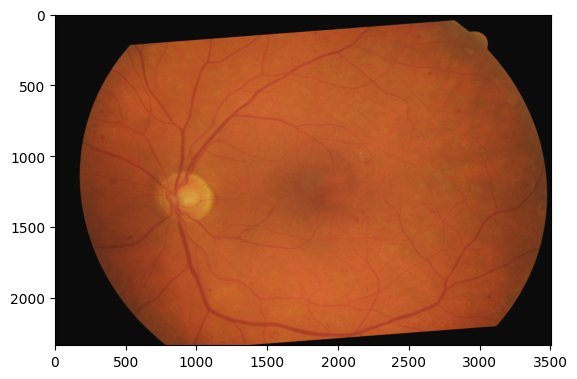

In [64]:
plt.imshow(aug["image"])

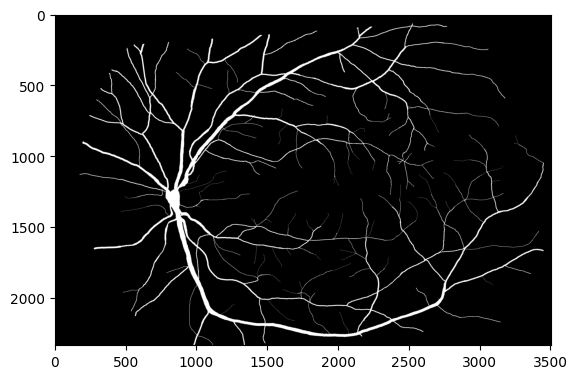

In [65]:
plt.imshow(aug["label"])